<a href="https://colab.research.google.com/github/ChoHyeonJun86/Perosnal_Project/blob/main/deeplearning_%EB%88%88_%EA%B0%90%EC%A7%80_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%85%8B_%EB%A1%9C%EB%93%9C_%EB%B0%8F_%EC%A0%84%EC%B2%98%EB%A6%AC_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python dlib imutils numpy matplotlib

In [2]:
from google.colab import files
files.upload()  # kaggle.json 파일 업로드

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"greenmush","key":"562ded252047f10a1d9ed0e6ab61db31"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install -q kaggle

In [5]:
# Drowsiness Detection Dataset (prasadvpatil) 다운로드
!kaggle datasets download -d prasadvpatil/mrl-dataset

# 다운로드된 파일 압축 해제
!unzip mrl-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/prasadvpatil/mrl-dataset
License(s): CC0-1.0
  0% 0.00/22.6M [00:00<?, ?B/s]
100% 22.6M/22.6M [00:00<00:00, 375MB/s]
Archive:  mrl-dataset.zip
  inflating: train/Closed_Eyes/s0001_00001_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00002_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00003_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00004_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00005_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00006_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00007_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00008_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00009_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00011_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00013_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00014_0_0_0_0_0_01.png  
  inflating: train/Closed_Eyes/s0001_00015_0_0_0_0_0_01.png  
  infl

훈련 데이터셋 로드 중...
Found 3200 images belonging to 2 classes.

검증 데이터셋 로드 중...
Found 800 images belonging to 2 classes.

--- 데이터셋 로드 정보 ---
훈련 데이터: 3200개 이미지, 2개 클래스
검증 데이터: 800개 이미지, 2개 클래스

클래스 인덱스:
{'Closed_Eyes': 0, 'Open_Eyes': 1}


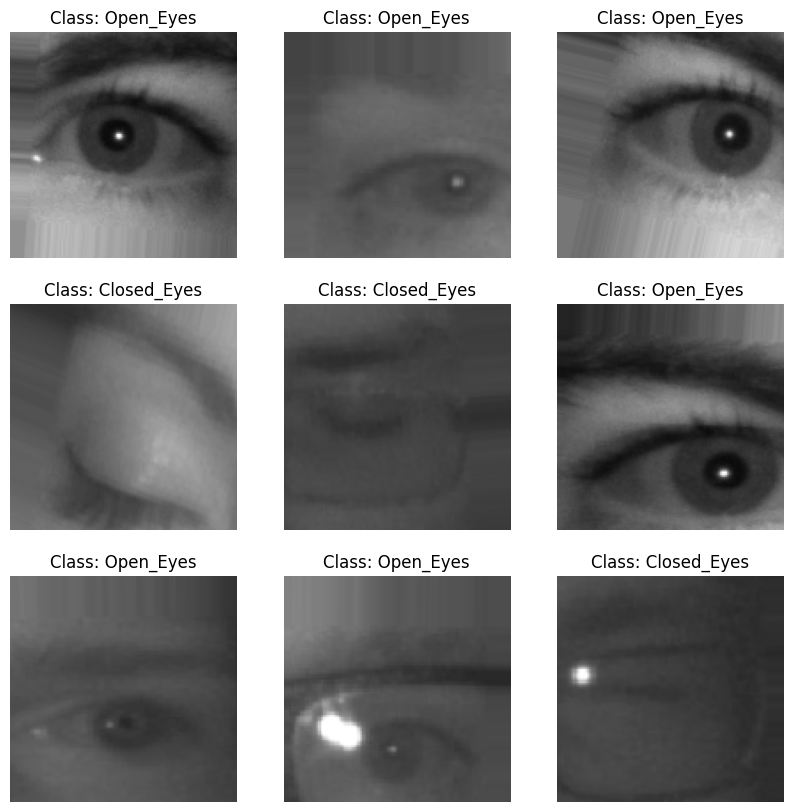

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋의 기본 경로 설정
# 'train' 폴더가 /content/ 바로 아래에 있으므로 base_dir을 /content/로 설정합니다.
base_dir = '/content' # 경로를 수정했습니다.
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
# valid_dir = os.path.join(base_dir, 'valid') # 'valid' 디렉토리가 있을 수 있으나,
                                          # 훈련 데이터에서 분리하는 방식을 유지합니다.

# 이미지 전처리 및 데이터 증강을 위한 ImageDataGenerator 설정
# rescale=1./255: 픽셀 값을 0-255에서 0-1 사이로 정규화하여 모델 학습 효율을 높입니다.
# validation_split=0.2: 훈련 데이터의 20%를 검증 데이터로 분리하여 사용합니다.
# 이는 별도의 'valid' 폴더가 없거나, 데이터셋에 검증 폴더가 없는 경우 유용합니다.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,        # 이미지를 20도까지 무작위 회전
    width_shift_range=0.2,    # 이미지를 가로로 0.2 (전체 너비의 20%)까지 무작위 이동
    height_shift_range=0.2,   # 이미지를 세로로 0.2 (전체 높이의 20%)까지 무작위 이동
    shear_range=0.2,          # 층밀림 변환(shear transformation) 적용
    zoom_range=0.2,           # 이미지를 0.2 (20%)까지 무작위 확대/축소
    horizontal_flip=True,     # 이미지를 무작위로 좌우 반전
    fill_mode='nearest',      # 변환 시 새로 생성되는 픽셀을 가장 가까운 픽셀로 채움
    validation_split=0.2      # 훈련 데이터의 20%를 검증 데이터로 분리
)

# 테스트 데이터는 모델 성능 평가에 사용되므로, 데이터 증강 없이 정규화만 수행합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

# 이미지 로드 및 데이터 증강 적용을 위한 flow_from_directory 설정
# target_size: 모든 이미지를 이 크기로 조정합니다. (예: 128x128 픽셀)
# batch_size: 한 번에 모델에 전달할 이미지의 수입니다.
# class_mode: 'binary'는 이진 분류(두 개의 클래스, 여기서는 Open_Eyes/Closed_Eyes)에 사용됩니다.
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

print("훈련 데이터셋 로드 중...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training', # 훈련 세트 지정
    seed=42, # 재현성을 위해 시드 설정
    shuffle=True # 훈련 데이터는 모델이 다양한 패턴을 학습하도록 섞어서 사용합니다.
)

print("\n검증 데이터셋 로드 중...")
validation_generator = train_datagen.flow_from_directory(
    train_dir, # 훈련 디렉토리에서 검증 데이터 분리
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation', # 검증 세트 지정
    seed=42, # 재현성을 위해 시드 설정
    shuffle=False # 검증 데이터는 성능 평가를 위해 순서를 유지합니다.
)

# 데이터셋 로드 결과 확인
print("\n--- 데이터셋 로드 정보 ---")
print(f"훈련 데이터: {train_generator.samples}개 이미지, {train_generator.num_classes}개 클래스")
print(f"검증 데이터: {validation_generator.samples}개 이미지, {validation_generator.num_classes}개 클래스")

# 클래스 인덱스 확인 (어떤 숫자가 어떤 클래스를 나타내는지)
# 예를 들어, {'Closed_Eyes': 0, 'Open_Eyes': 1} 와 같이 출력될 수 있습니다.
print("\n클래스 인덱스:")
print(train_generator.class_indices)

# 첫 번째 배치 이미지 시각화

x_batch, y_batch = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(min(9, BATCH_SIZE)): # 최대 9개 이미지 시각화 (또는 배치 크기 내에서)
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    # 클래스 인덱스를 실제 클래스 이름으로 변환하여 제목에 표시
    class_labels = {v: k for k, v in train_generator.class_indices.items()}
    plt.title(f"Class: {class_labels[y_batch[i]]}")
    plt.axis('off')
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 174ms/step - accuracy: 0.9837 - loss: 0.0403 - val_accuracy: 0.9162 - val_loss: 0.2319
Epoch 23/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9900 - loss: 0.0338
Epoch 23: val_accuracy did not improve from 0.91625
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 193ms/step - accuracy: 0.9900 - loss: 0.0338 - val_accuracy: 0.8338 - val_loss: 0.5645
Epoch 24/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9882 - loss: 0.0389
Epoch 24: val_accuracy did not improve from 0.91625
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 205ms/step - accuracy: 0.9882 - loss: 0.0390 - val_accuracy: 0.9137 - val_loss: 0.2452
Epoch 25/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9918 - loss: 0.0262
Epoch 25: val_accuracy did not improve from 0.91625
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.8487 - val_loss: 0.4885
Epoch 26/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9935 - loss: 0.0294
Epoch 26

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.9919 - loss: 0.0330 - val_accuracy: 0.9350 - val_loss: 0.2103
Epoch 32/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9941 - loss: 0.0175
Epoch 32: val_accuracy did not improve from 0.93500
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.9940 - loss: 0.0177 - val_accuracy: 0.8975 - val_loss: 0.2907
Epoch 33/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9885 - loss: 0.0379
Epoch 33: val_accuracy did not improve from 0.93500
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.9885 - loss: 0.0378 - val_accuracy: 0.9150 - val_loss: 0.2657
Epoch 34/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9939 - loss: 0.0175
Epoch 34: val_accuracy did not improve from 0.93500
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 193ms/step - accuracy: 0.9939 - loss: 0.0176 - val_accuracy: 0.8225 - val_loss: 0.5549
Epoch 35/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9893 - loss: 0.0251
Epoch 35

100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.9935 - loss: 0.0290 - val_accuracy: 0.9463 - val_loss: 0.1646
Epoch 37/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9948 - loss: 0.0150
Epoch 37: val_accuracy did not improve from 0.94625
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.9948 - loss: 0.0149 - val_accuracy: 0.8725 - val_loss: 0.4187
Epoch 38/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9929 - loss: 0.0233
Epoch 38: val_accuracy did not improve from 0.94625
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.9929 - loss: 0.0233 - val_accuracy: 0.9112 - val_loss: 0.2252
Epoch 39/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9962 - loss: 0.0132
Epoch 39: val_accuracy improved from 0.94625 to 0.95375, saving model to best_drowsiness_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 0.9538 - val_loss: 0.1128
Epoch 40/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9934 - loss: 0.0249
Epoch 40: val_accuracy did not improve from 0.95375
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 193ms/step - accuracy: 0.9934 - loss: 0.0249 - val_accuracy: 0.9500 - val_loss: 0.1114
Epoch 41/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9949 - loss: 0.0182
Epoch 41: val_accuracy did not improve from 0.95375
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.9949 - loss: 0.0183 - val_accuracy: 0.9488 - val_loss: 0.1582
Epoch 42/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9958 - loss: 0.0237
Epoch 42: val_accuracy did not improve from 0.95375
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 191ms/step - accuracy: 0.9957 - loss: 0.0238 - val_accuracy: 0.9388 - val_loss: 0.1592
Epoch 43/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9945 - loss: 0.0142
Epoch 43

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 174ms/step - accuracy: 0.9903 - loss: 0.0289 - val_accuracy: 0.9625 - val_loss: 0.1072
Epoch 49/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9951 - loss: 0.0133
Epoch 49: val_accuracy did not improve from 0.96250
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - accuracy: 0.9951 - loss: 0.0133 - val_accuracy: 0.9025 - val_loss: 0.3197
Epoch 50/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9936 - loss: 0.0160
Epoch 50: val_accuracy did not improve from 0.96250
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.9936 - loss: 0.0160 - val_accuracy: 0.9187 - val_loss: 0.3220

모델 학습 완료.


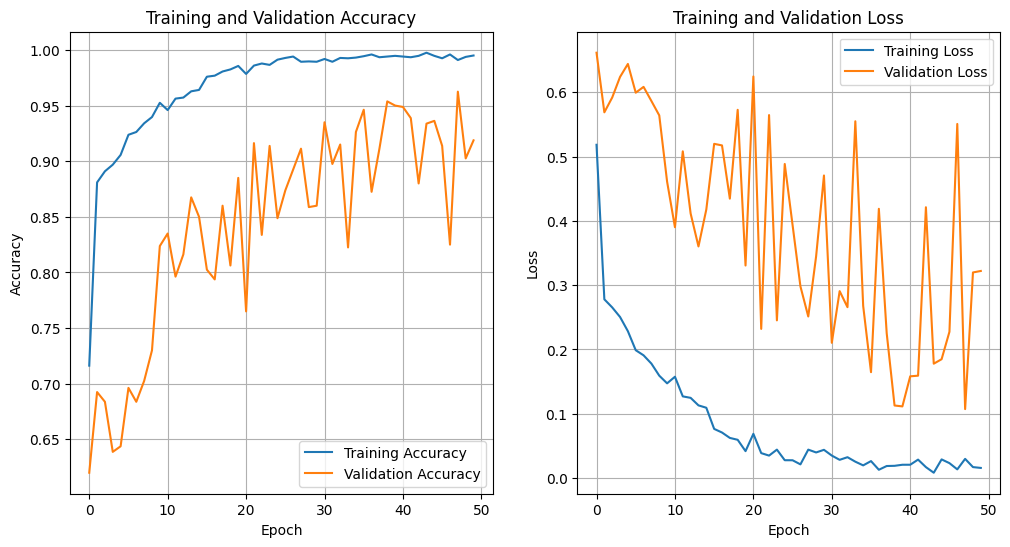


학습 결과 시각화 완료.


In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- 1. 모델 구축 ---
# 간단한 CNN 모델 정의
def create_cnn_model(input_shape):
    model = models.Sequential([
        # 첫 번째 합성곱 블록
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # 과적합 방지를 위한 Dropout 추가

        # 두 번째 합성곱 블록
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # 세 번째 합성곱 블록
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # 특징 맵을 1차원 벡터로 평탄화 (완전 연결 층에 입력하기 위함)
        layers.Flatten(),

        # 완전 연결 층
        layers.Dense(256, activation='relu'), # 뉴런 256개
        layers.Dropout(0.5), # 과적합 방지를 위한 Dropout 추가

        # 출력 층
        # 이진 분류 (눈 감김/떠짐)이므로 sigmoid 활성화 함수를 사용합니다.
        # 출력 뉴런은 1개입니다.
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# 모델 생성
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3) # 컬러 이미지이므로 채널이 3
model = create_cnn_model(input_shape)

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
model.summary()

# 모델 컴파일
# optimizer: Adam은 일반적으로 좋은 성능을 보이는 최적화 알고리즘입니다.
# loss: 이진 분류이므로 binary_crossentropy를 사용합니다.
# metrics: 학습 및 평가 시 모니터링할 지표 (여기서는 정확도)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- 2. 모델 학습 ---
# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
# EarlyStopping: 검증 손실이 개선되지 않으면 학습을 조기 종료하여 과적합 방지
# patience: 몇 epoch 동안 개선이 없으면 조기 종료할지 지정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: 검증 정확도가 가장 높은 모델을 저장
# save_best_only=True: 가장 좋은 성능을 보이는 모델만 저장
model_checkpoint = ModelCheckpoint(
    'best_drowsiness_model.h5', # 저장될 모델 파일 이름
    monitor='val_accuracy',
    mode='max', # val_accuracy는 높을수록 좋으므로 'max'
    save_best_only=True,
    verbose=1 # 저장 시 메시지 출력
)

# 모델 학습
# epochs: 전체 훈련 데이터를 몇 번 반복하여 학습할지
# validation_data: 학습 중 모델 성능을 검증할 데이터셋
# callbacks: 위에 정의한 콜백 함수들
print("\n모델 학습 시작...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # 한 epoch당 steps 수
    epochs=50, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # 한 epoch당 검증 steps 수
    callbacks=[early_stopping, model_checkpoint]
)

print("\n모델 학습 완료.")

# --- 3. 학습 결과 시각화 ---
# 학습 과정의 정확도와 손실 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

print("\n학습 결과 시각화 완료.")


훈련 데이터셋 로드 중...
Found 3200 images belonging to 2 classes.

검증 데이터셋 로드 중...
Found 800 images belonging to 2 classes.

테스트 데이터셋 로드 중...
경고: '/content/test' 디렉토리가 없습니다. 테스트 데이터셋을 로드할 수 없습니다.

--- 데이터셋 로드 정보 ---
훈련 데이터: 3200개 이미지, 2개 클래스
검증 데이터: 800개 이미지, 2개 클래스
테스트 데이터: 로드되지 않음 (디렉토리 없음)

클래스 인덱스:
{'Closed_Eyes': 0, 'Open_Eyes': 1}


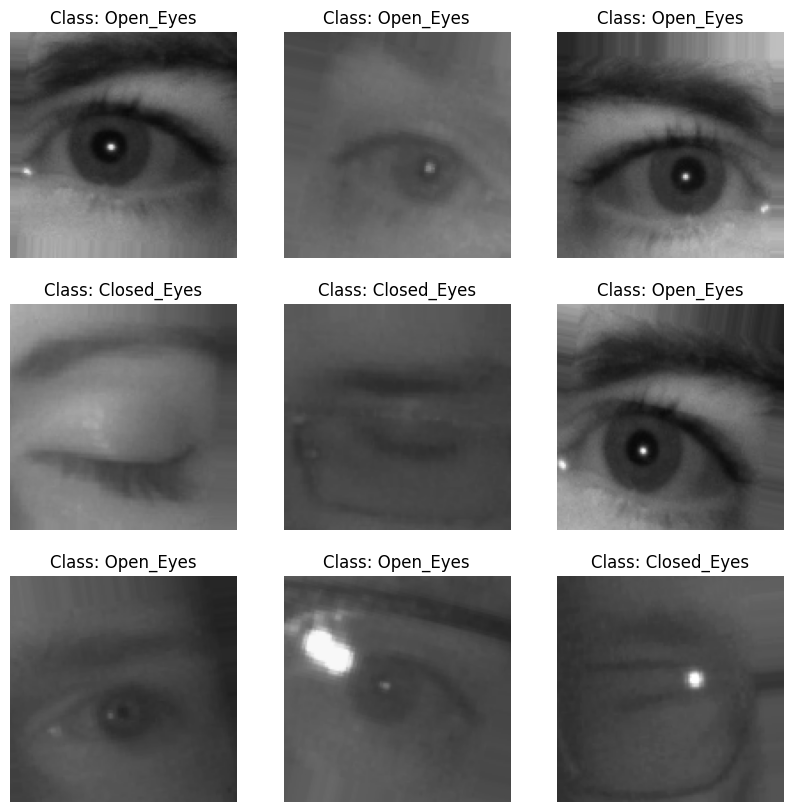

In [11]:
base_dir = '/content' # 경로를 수정했습니다.
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
# valid_dir = os.path.join(base_dir, 'valid') # 'valid' 디렉토리가 있을 수 있으나,
                                          # 훈련 데이터에서 분리하는 방식을 유지합니다.

# 이미지 전처리 및 데이터 증강을 위한 ImageDataGenerator 설정
# rescale=1./255: 픽셀 값을 0-255에서 0-1 사이로 정규화하여 모델 학습 효율을 높입니다.
# validation_split=0.2: 훈련 데이터의 20%를 검증 데이터로 분리하여 사용합니다.
# 이는 별도의 'valid' 폴더가 없거나, 데이터셋에 검증 폴더가 없는 경우 유용합니다.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,        # 이미지를 15도까지 무작위 회전 (기존 30도에서 감소)
    width_shift_range=0.1,    # 이미지를 가로로 0.1 (전체 너비의 10%)까지 무작위 이동 (기존 0.25에서 감소)
    height_shift_range=0.1,   # 이미지를 세로로 0.1 (전체 높이의 10%)까지 무작위 이동 (기존 0.25에서 감소)
    shear_range=0.1,          # 층밀림 변환(shear transformation) 적용 (기존 0.25에서 감소)
    zoom_range=0.1,           # 이미지를 0.1 (10%)까지 무작위 확대/축소 (기존 0.25에서 감소)
    horizontal_flip=True,     # 이미지를 무작위로 좌우 반전
    brightness_range=[0.9, 1.1], # 밝기 변화 (원본 밝기의 90%~110% 사이, 기존 [0.7, 1.3]에서 감소)
    channel_shift_range=0.05, # 채널 값 무작위 변화 (기존 0.1에서 감소)
    fill_mode='nearest',      # 변환 시 새로 생성되는 픽셀을 가장 가까운 픽셀로 채움
    validation_split=0.2      # 훈련 데이터의 20%를 검증 데이터로 분리
)

# 테스트 데이터는 모델 성능 평가에 사용되므로, 데이터 증강 없이 정규화만 수행합니다.
test_datagen = ImageDataGenerator(rescale=1./255)

print("훈련 데이터셋 로드 중...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training', # 훈련 세트 지정
    seed=42, # 재현성을 위해 시드 설정
    shuffle=True # 훈련 데이터는 모델이 다양한 패턴을 학습하도록 섞어서 사용합니다.
)

print("\n검증 데이터셋 로드 중...")
validation_generator = train_datagen.flow_from_directory(
    train_dir, # 훈련 디렉토리에서 검증 데이터 분리
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation', # 검증 세트 지정
    seed=42, # 재현성을 위해 시드 설정
    shuffle=False # 검증 데이터는 성능 평가를 위해 순서를 유지합니다.
)

print("\n테스트 데이터셋 로드 중...")
# 테스트 디렉토리가 존재하는지 확인
if os.path.exists(test_dir):
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_WIDTH, IMG_HEIGHT),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False # 테스트 데이터도 성능 평가를 위해 순서를 유지합니다.
    )
    print(f"'{test_dir}'에서 테스트 데이터셋을 로드했습니다.")
else:
    print(f"경고: '{test_dir}' 디렉토리가 없습니다. 테스트 데이터셋을 로드할 수 없습니다.")
    test_generator = None # 테스트 데이터셋 로드 실패를 표시

# 데이터셋 로드 결과 확인
print("\n--- 데이터셋 로드 정보 ---")
print(f"훈련 데이터: {train_generator.samples}개 이미지, {train_generator.num_classes}개 클래스")
print(f"검증 데이터: {validation_generator.samples}개 이미지, {validation_generator.num_classes}개 클래스")
# test_generator가 None이 아닐 경우에만 정보 출력
if test_generator:
    print(f"테스트 데이터: {test_generator.samples}개 이미지, {test_generator.num_classes}개 클래스")
else:
    print("테스트 데이터: 로드되지 않음 (디렉토리 없음)")


# 클래스 인덱스 확인 (어떤 숫자가 어떤 클래스를 나타내는지)
# 예를 들어, {'Closed_Eyes': 0, 'Open_Eyes': 1} 와 같이 출력될 수 있습니다.
print("\n클래스 인덱스:")
print(train_generator.class_indices)

x_batch, y_batch = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(min(9, BATCH_SIZE)): # 최대 9개 이미지 시각화 (또는 배치 크기 내에서)
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    # 클래스 인덱스를 실제 클래스 이름으로 변환하여 제목에 표시
    class_labels = {v: k for k, v in train_generator.class_indices.items()}
    plt.title(f"Class: {class_labels[y_batch[i]]}")
    plt.axis('off')
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9702 - loss: 0.0835 - val_accuracy: 0.8775 - val_loss: 0.2627
Epoch 26/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9786 - loss: 0.0572
Epoch 26: val_accuracy improved from 0.87750 to 0.88375, saving model to best_drowsiness_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.9786 - loss: 0.0573 - val_accuracy: 0.8838 - val_loss: 0.2831
Epoch 27/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9732 - loss: 0.0697
Epoch 27: val_accuracy did not improve from 0.88375
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 213ms/step - accuracy: 0.9732 - loss: 0.0697 - val_accuracy: 0.8025 - val_loss: 0.4509
Epoch 28/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9810 - loss: 0.0556
Epoch 28: val_accuracy did not improve from 0.88375
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.9810 - loss: 0.0557 - val_accuracy: 0.8375 - val_loss: 0.3286
Epoch 29/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9829 - loss: 0.0551
Epoch 29: val_accuracy did not improve from 0.88375
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.9829 - loss: 0.0551 - val_accuracy: 0.8637 - val_loss: 0.2991
Epoch 30/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9816 - loss: 0.0491
Epoch 30

100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 208ms/step - accuracy: 0.9809 - loss: 0.0588 - val_accuracy: 0.9225 - val_loss: 0.1893
Epoch 36/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9860 - loss: 0.0396
Epoch 36: val_accuracy did not improve from 0.92250
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.9860 - loss: 0.0396 - val_accuracy: 0.8712 - val_loss: 0.3108
Epoch 37/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9826 - loss: 0.0678
Epoch 37: val_accuracy did not improve from 0.92250
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 216ms/step - accuracy: 0.9826 - loss: 0.0678 - val_accuracy: 0.8800 - val_loss: 0.2630
Epoch 38/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9884 - loss: 0.0367
Epoch 38: val_accuracy improved from 0.92250 to 0.93625, saving model to best_drowsiness_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9884 - loss: 0.0367 - val_accuracy: 0.9362 - val_loss: 0.1481
Epoch 39/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9891 - loss: 0.0370
Epoch 39: val_accuracy did not improve from 0.93625
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.9891 - loss: 0.0371 - val_accuracy: 0.9300 - val_loss: 0.1739
Epoch 40/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9810 - loss: 0.0648
Epoch 40: val_accuracy did not improve from 0.93625
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - accuracy: 0.9811 - loss: 0.0647 - val_accuracy: 0.9187 - val_loss: 0.1883
Epoch 41/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9849 - loss: 0.0369
Epoch 41: val_accuracy did not improve from 0.93625
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - accuracy: 0.9849 - loss: 0.0369 - val_accuracy: 0.8612 - val_loss: 0.3551
Epoch 42/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9832 - loss: 0.0594
Epoch 42

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.9908 - loss: 0.0367 - val_accuracy: 0.9400 - val_loss: 0.1483
Epoch 48/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9839 - loss: 0.0462
Epoch 48: val_accuracy did not improve from 0.94000
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 220ms/step - accuracy: 0.9840 - loss: 0.0462 - val_accuracy: 0.9262 - val_loss: 0.1986

모델 학습 완료.


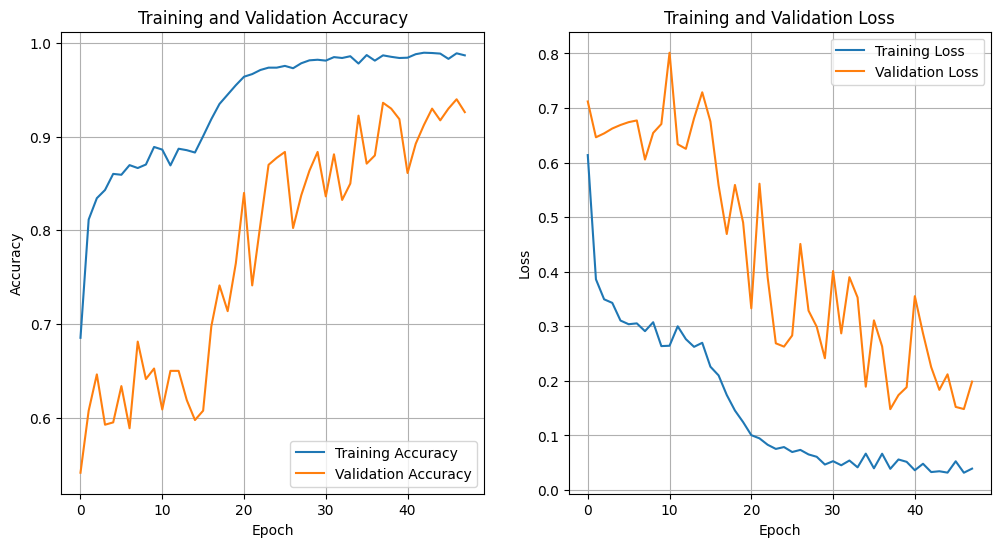


학습 결과 시각화 완료.


In [16]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

# --- 1. 모델 구축 ---
# 간단한 CNN 모델 정의
def create_cnn_model(input_shape):
    model = models.Sequential([
        # 첫 번째 합성곱 블록
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # 과적합 방지를 위한 Dropout 추가

        # 두 번째 합성곱 블록
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # 세 번째 합성곱 블록
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # 특징 맵을 1차원 벡터로 평탄화 (완전 연결 층에 입력하기 위함)
        layers.Flatten(),

        # 완전 연결 층
        layers.Dense(256, activation='relu'), # 뉴런 256개
        layers.Dropout(0.5), # 과적합 방지를 위한 Dropout 추가

        # 출력 층
        # 이진 분류 (눈 감김/떠짐)이므로 sigmoid 활성화 함수를 사용합니다.
        # 출력 뉴런은 1개입니다.
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# 모델 생성
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3) # 컬러 이미지이므로 채널이 3
model = create_cnn_model(input_shape)

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
model.summary()

# 모델 컴파일
# optimizer: Adam은 일반적으로 좋은 성능을 보이는 최적화 알고리즘입니다.
# loss: 이진 분류이므로 binary_crossentropy를 사용합니다.
# metrics: 학습 및 평가 시 모니터링할 지표 (여기서는 정확도)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- 2. 모델 학습 ---
# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
# EarlyStopping: 검증 손실이 개선되지 않으면 학습을 조기 종료하여 과적합 방지
# patience: 몇 epoch 동안 개선이 없으면 조기 종료할지 지정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: 검증 정확도가 가장 높은 모델을 저장
# save_best_only=True: 가장 좋은 성능을 보이는 모델만 저장
model_checkpoint = ModelCheckpoint(
    'best_drowsiness_model.h5', # 저장될 모델 파일 이름
    monitor='val_accuracy',
    mode='max', # val_accuracy는 높을수록 좋으므로 'max'
    save_best_only=True,
    verbose=1 # 저장 시 메시지 출력
)

# 모델 학습
# epochs: 전체 훈련 데이터를 몇 번 반복하여 학습할지
# validation_data: 학습 중 모델 성능을 검증할 데이터셋
# callbacks: 위에 정의한 콜백 함수들
print("\n모델 학습 시작...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # 한 epoch당 steps 수
    epochs=50, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # 한 epoch당 검증 steps 수
    callbacks=[early_stopping, model_checkpoint]
)

print("\n모델 학습 완료.")

# --- 3. 학습 결과 시각화 ---
# 학습 과정의 정확도와 손실 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

print("\n학습 결과 시각화 완료.")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,209 (24.86 MB)

 Trainable params: 6,517,249 (24.86 MB)

 Non-trainable params: 960 (3.75 KB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.9494 - loss: 0.1340 - val_accuracy: 0.5238 - val_loss: 0.7696
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9470 - loss: 0.1358
Epoch 9: val_accuracy improved from 0.52375 to 0.80125, saving model to best_drowsiness_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.9470 - loss: 0.1357 - val_accuracy: 0.8012 - val_loss: 0.4247
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9663 - loss: 0.1172
Epoch 10: val_accuracy did not improve from 0.80125
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.9663 - loss: 0.1171 - val_accuracy: 0.5188 - val_loss: 3.6724
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9720 - loss: 0.0924
Epoch 11: val_accuracy did not improve from 0.80125
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 222ms/step - accuracy: 0.9720 - loss: 0.0923 - val_accuracy: 0.5625 - val_loss: 2.2746
Epoch 12/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9683 - loss: 0.1003
Epoch 12: val_accuracy did not improve from 0.80125
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.9683 - loss: 0.1002 - val_accuracy: 0.6913 - val_loss: 0.9127
Epoch 13/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9766 - loss: 0.0688
Epoch 13

100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 246ms/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.8600 - val_loss: 0.4010
Epoch 16/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9762 - loss: 0.0700
Epoch 16: val_accuracy improved from 0.86000 to 0.87875, saving model to best_drowsiness_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 222ms/step - accuracy: 0.9762 - loss: 0.0699 - val_accuracy: 0.8788 - val_loss: 0.3476
Epoch 17/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9794 - loss: 0.0606
Epoch 17: val_accuracy did not improve from 0.87875
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9794 - loss: 0.0607 - val_accuracy: 0.8200 - val_loss: 0.5442
Epoch 18/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9839 - loss: 0.0673
Epoch 18: val_accuracy did not improve from 0.87875
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.9839 - loss: 0.0672 - val_accuracy: 0.8537 - val_loss: 0.4363
Epoch 19/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9874 - loss: 0.0561
Epoch 19: val_accuracy did not improve from 0.87875
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.9874 - loss: 0.0561 - val_accuracy: 0.6212 - val_loss: 1.4481
Epoch 20/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9779 - loss: 0.0725
Epoch 20

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 224ms/step - accuracy: 0.9779 - loss: 0.0725 - val_accuracy: 0.9525 - val_loss: 0.1328
Epoch 21/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9820 - loss: 0.0607
Epoch 21: val_accuracy did not improve from 0.95250
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 214ms/step - accuracy: 0.9820 - loss: 0.0606 - val_accuracy: 0.9187 - val_loss: 0.1960
Epoch 22/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9853 - loss: 0.0484
Epoch 22: val_accuracy did not improve from 0.95250
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - accuracy: 0.9853 - loss: 0.0484 - val_accuracy: 0.9475 - val_loss: 0.1576
Epoch 23/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9811 - loss: 0.0613
Epoch 23: val_accuracy did not improve from 0.95250
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9812 - loss: 0.0613 - val_accuracy: 0.7900 - val_loss: 0.5839
Epoch 24/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9913 - loss: 0.0368
Epoch 24

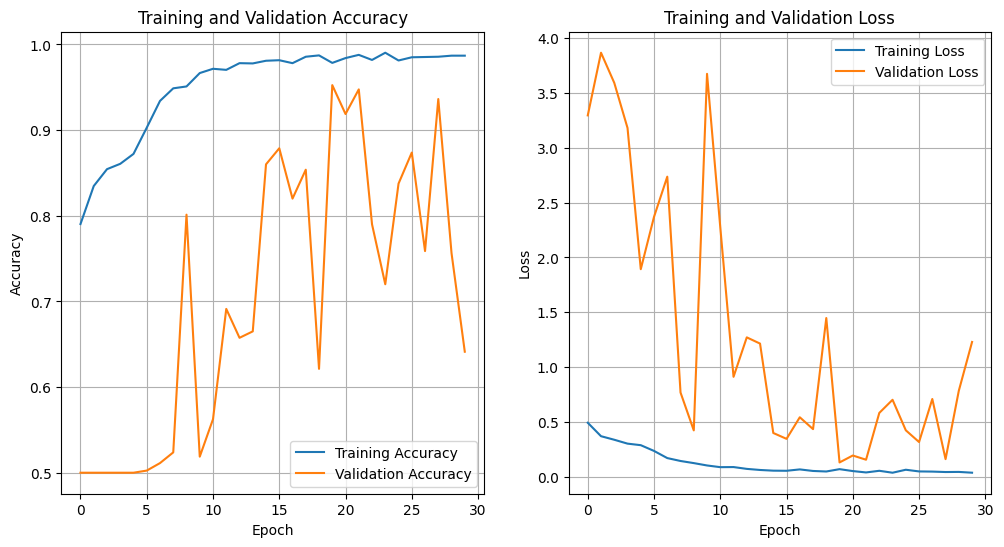

In [17]:
# --- 1. 모델 구축 ---
# 간단한 CNN 모델 정의
def create_cnn_model(input_shape):
    model = models.Sequential([
        # 첫 번째 합성곱 블록
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(), # 배치 정규화 추가
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3), # Dropout 비율 0.25 -> 0.3으로 증가

        # 두 번째 합성곱 블록
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(), # 배치 정규화 추가
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3), # Dropout 비율 0.25 -> 0.3으로 증가

        # 세 번째 합성곱 블록
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(), # 배치 정규화 추가
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3), # Dropout 비율 0.25 -> 0.3으로 증가

        # 특징 맵을 1차원 벡터로 평탄화 (완전 연결 층에 입력하기 위함)
        layers.Flatten(),

        # 완전 연결 층
        layers.Dense(256, activation='relu'), # 뉴런 256개
        layers.BatchNormalization(), # 배치 정규화 추가
        layers.Dropout(0.6), # Dropout 비율 0.5 -> 0.6으로 증가

        # 출력 층
        # 이진 분류 (눈 감김/떠짐)이므로 sigmoid 활성화 함수를 사용합니다.
        # 출력 뉴런은 1개입니다.
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# 모델 생성
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3) # 컬러 이미지이므로 채널이 3
model = create_cnn_model(input_shape)

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
model.summary()

# 모델 컴파일
# optimizer: Adam은 일반적으로 좋은 성능을 보이는 최적화 알고리즘입니다.
# loss: 이진 분류이므로 binary_crossentropy를 사용합니다.
# metrics: 학습 및 평가 시 모니터링할 지표 (여기서는 정확도)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- 2. 모델 학습 ---
# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
# EarlyStopping: 검증 손실이 개선되지 않으면 학습을 조기 종료하여 과적합 방지
# patience: 몇 epoch 동안 개선이 없으면 조기 종료할지 지정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ModelCheckpoint: 검증 정확도가 가장 높은 모델을 저장
# save_best_only=True: 가장 좋은 성능을 보이는 모델만 저장
model_checkpoint = ModelCheckpoint(
    'best_drowsiness_model.h5', # 저장될 모델 파일 이름
    monitor='val_accuracy',
    mode='max', # val_accuracy는 높을수록 좋으므로 'max'
    save_best_only=True,
    verbose=1 # 저장 시 메시지 출력
)

# 모델 학습
# epochs: 전체 훈련 데이터를 몇 번 반복하여 학습할지
# validation_data: 학습 중 모델 성능을 검증할 데이터셋
# callbacks: 위에 정의한 콜백 함수들
print("\n모델 학습 시작...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # 한 epoch당 steps 수
    epochs=50, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # 한 epoch당 검증 steps 수
    callbacks=[early_stopping, model_checkpoint]
)

print("\n모델 학습 완료.")

# --- 3. 학습 결과 시각화 ---
# 학습 과정의 정확도와 손실 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

--- 사용자 정의 CNN 모델 요약 ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,209 (24.86 MB)

 Trainable params: 6,517,249 (24.86 MB)

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.9533 - loss: 0.3816 - val_accuracy: 0.6325 - val_loss: 1.3494
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9784 - loss: 0.2766
Epoch 11: val_accuracy improved from 0.63250 to 0.88000, saving model to best_drowsiness_model_custom_cnn.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 216ms/step - accuracy: 0.9783 - loss: 0.2766 - val_accuracy: 0.8800 - val_loss: 0.4986
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9703 - loss: 0.2739
Epoch 12: val_accuracy did not improve from 0.88000
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.9704 - loss: 0.2739 - val_accuracy: 0.8025 - val_loss: 0.6581
Epoch 13/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9728 - loss: 0.2716
Epoch 13: val_accuracy improved from 0.88000 to 0.90750, saving model to best_drowsiness_model_custom_cnn.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.9728 - loss: 0.2717 - val_accuracy: 0.9075 - val_loss: 0.4100
Epoch 14/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9758 - loss: 0.2865
Epoch 14: val_accuracy did not improve from 0.90750
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.9758 - loss: 0.2865 - val_accuracy: 0.8300 - val_loss: 0.6048
Epoch 15/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9778 - loss: 0.2966
Epoch 15: val_accuracy improved from 0.90750 to 0.92000, saving model to best_drowsiness_model_custom_cnn.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.9778 - loss: 0.2964 - val_accuracy: 0.9200 - val_loss: 0.3819
Epoch 16/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9779 - loss: 0.2683
Epoch 16: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.9779 - loss: 0.2683 - val_accuracy: 0.7775 - val_loss: 0.7426
Epoch 17/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9744 - loss: 0.2704
Epoch 17: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 215ms/step - accuracy: 0.9744 - loss: 0.2705 - val_accuracy: 0.9137 - val_loss: 0.4483
Epoch 18/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9793 - loss: 0.2782
Epoch 18: val_accuracy did not improve from 0.92000
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 206ms/step - accuracy: 0.9793 - loss: 0.2782 - val_accuracy: 0.7150 - val_loss: 1.1129
Epoch 19/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9848 - loss: 0.2755
Epoc

100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.9836 - loss: 0.2537 - val_accuracy: 0.9438 - val_loss: 0.3650
Epoch 23/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9805 - loss: 0.2679
Epoch 23: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 220ms/step - accuracy: 0.9805 - loss: 0.2679 - val_accuracy: 0.8100 - val_loss: 0.6487
Epoch 24/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9817 - loss: 0.2699
Epoch 24: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9817 - loss: 0.2700 - val_accuracy: 0.6612 - val_loss: 1.0666
Epoch 25/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9877 - loss: 0.2557
Epoch 25: val_accuracy did not improve from 0.94375
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 213ms/step - accuracy: 0.9876 - loss: 0.2556 - val_accuracy: 0.6950 - val_loss: 1.2371
Epoch 26/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9832 - loss: 0.2636
Epoc

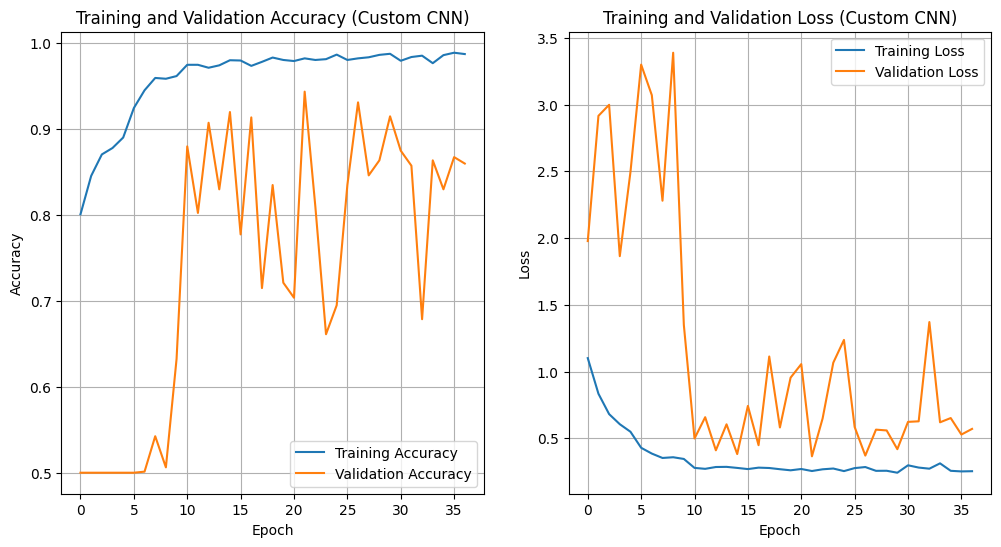


학습 결과 시각화 완료.
눈 감지 모델 (사용자 정의 CNN)이 Google Drive에 저장되었습니다.


In [18]:
# --- 1. 모델 구축 (L2 정규화 적용) ---
def create_custom_cnn_model(input_shape):
    model = models.Sequential([
        # 첫 번째 합성곱 블록
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(), # 배치 정규화
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # 드롭아웃

        # 두 번째 합성곱 블록
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(), # 배치 정규화
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # 드롭아웃

        # 세 번째 합성곱 블록
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(), # 배치 정규화
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25), # 드롭아웃

        # 특징 맵을 1차원 벡터로 평탄화
        layers.Flatten(),

        # 완전 연결 층
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # L2 정규화 적용
        layers.BatchNormalization(), # 배치 정규화
        layers.Dropout(0.5), # 드롭아웃

        # 출력 층 (이진 분류)
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# 사용자 정의 CNN 모델 생성
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3) # 컬러 이미지이므로 채널이 3
eye_detection_model = create_custom_cnn_model(input_shape) # 변수명을 eye_detection_model로 통일

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
print("--- 사용자 정의 CNN 모델 요약 ---")
eye_detection_model.summary()

# 모델 컴파일
eye_detection_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- 2. 모델 학습 ---
# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # patience를 더 길게 설정 (과적합 민감할 수 있음)

# ModelCheckpoint: 검증 정확도가 가장 높은 모델을 저장
model_checkpoint = ModelCheckpoint(
    'best_drowsiness_model_custom_cnn.h5', # 저장될 모델 파일 이름 변경
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 모델 학습
print("\n모델 학습 시작 (사용자 정의 CNN)...")
history = eye_detection_model.fit( # 모델 학습 객체명을 eye_detection_model로 통일
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # 한 epoch당 steps 수
    epochs=100, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도 (이전 50에서 증가)
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # 한 epoch당 검증 steps 수
    callbacks=[early_stopping, model_checkpoint]
)

print("\n모델 학습 완료.")

# --- 3. 학습 결과 시각화 ---
# 학습 과정의 정확도와 손실 그래프
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Custom CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Custom CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

print("\n학습 결과 시각화 완료.")

# --- 모델 저장 (Google Drive 경로로 직접 지정) ---
# 이 코드는 모델 학습이 완료된 후에 실행해야 합니다.
eye_detection_model.save('/content/drive/MyDrive/best_drowsiness_model_custom_cnn.h5') # 저장 파일 이름 변경
print("눈 감지 모델 (사용자 정의 CNN)이 Google Drive에 저장되었습니다.")


--- 눈 감지 모델 초기 요약 (헤드만 학습 가능) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

...

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


눈 감지 모델 미세 조정 학습 시작...
Epoch 43/62
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9961 - loss: 0.0226
Epoch 43: val_accuracy improved from -inf to 0.96625, saving model to best_drowsiness_model_finetuned.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 235ms/step - accuracy: 0.9961 - loss: 0.0226 - val_accuracy: 0.9663 - val_loss: 0.0932
Epoch 44/62
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9990 - loss: 0.0199
Epoch 44: val_accuracy did not improve from 0.96625
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 202ms/step - accuracy: 0.9990 - loss: 0.0199 - val_accuracy: 0.9450 - val_loss: 0.1516
Epoch 45/62
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9980 - loss: 0.0206
Epoch 45: val_accuracy did not improve from 0.96625
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.9980 - loss: 0.0206 - val_accuracy: 0.9625 - val_loss: 0.1172
Epoch 46/62
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9978 - loss: 0.0194
Epoch 46: val_accuracy did not improve from 0.96625
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 195ms/step - accuracy: 0.9978 - loss: 0.0194 - val_accuracy: 0.9525 - val_loss: 0.1505
Epoch 47/62
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9949 - loss: 0.0237
Epoch 47

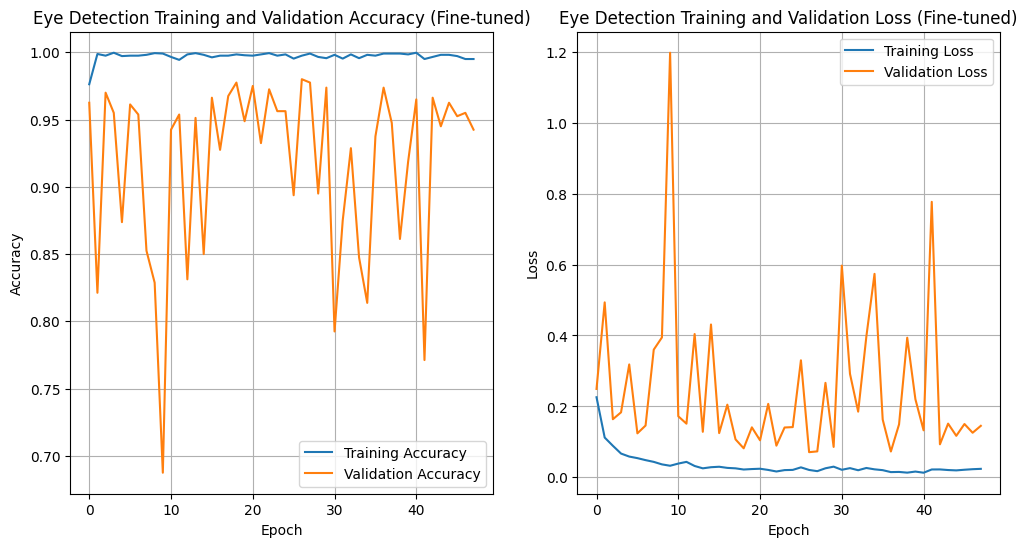


최종 학습 결과 시각화 완료.
눈 감지 모델 (전이 학습 미세 조정)이 Google Drive에 저장되었습니다.


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os # 파일 존재 여부 확인을 위해 os 모듈 추가

# 이전에 정의된 IMG_WIDTH, IMG_HEIGHT, BATCH_SIZE는 이전 코드 셀에서 사용되었으므로,
# 현재 셀에서 사용하려면 다시 정의하거나, 이전 셀이 실행되어 변수들이 전역적으로 사용 가능해야 합니다.
# 안전을 위해 여기서 다시 정의합니다.ㅃ
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

# --- 1. 모델 구축 (전이 학습 적용 - 헤드 학습 준비) ---
# 사전 학습된 MobileNetV2 모델을 로드하여 전이 학습을 적용합니다.
# include_top=False: 분류 층(fully connected layers)은 제외하고 특징 추출 부분만 가져옵니다.
# weights='imagenet': ImageNet 데이터셋으로 사전 학습된 가중치를 사용합니다.
# input_shape: 모델에 입력될 이미지의 크기를 정의합니다.
base_model = applications.MobileNetV2(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
    include_top=False,
    weights='imagenet'
)

# 베이스 모델의 층들을 동결(freeze)하여 학습되지 않도록 합니다.
# 1단계 학습 시 베이스 모델의 가중치는 고정합니다.
base_model.trainable = False

# 새로운 분류 층(classification head)을 베이스 모델 위에 추가합니다.
def create_transfer_learning_model(base_model, input_shape):
    model = models.Sequential([
        base_model, # 사전 학습된 MobileNetV2 모델
        layers.GlobalAveragePooling2D(), # 특징 맵의 공간 차원을 줄입니다.
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # L2 정규화 적용
        layers.BatchNormalization(), # 학습 안정화를 위한 배치 정규화
        layers.Dropout(0.5), # 과적합 방지를 위한 드롭아웃
        layers.Dense(1, activation='sigmoid') # 이진 분류를 위한 출력 층
    ])
    return model

# 눈 감지 모델 생성
eye_detection_model = create_transfer_learning_model(base_model, (IMG_WIDTH, IMG_HEIGHT, 3))

# 모델 요약 출력 (층별 구조와 파라미터 수 확인)
print("--- 눈 감지 모델 초기 요약 (헤드만 학습 가능) ---")
eye_detection_model.summary()

# 모델 컴파일 (1단계: 헤드 학습)
# 옵티마이저는 'adam'을 사용하며, 특별히 학습률을 지정하지 않으면 기본값(0.001)이 사용됩니다.
eye_detection_model.compile(optimizer='adam',
                            loss='binary_crossentropy',
                            metrics=['accuracy'])

# --- 2. 눈 감지 모델 학습 (1단계: 헤드 학습) ---
print("\n눈 감지 모델 학습 시작 (1단계: 헤드 학습)...")

# 콜백 함수 설정 (모델 학습을 효율적으로 제어)
early_stopping_head = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True) # patience를 15로 변경
model_checkpoint_head = ModelCheckpoint(
    'best_drowsiness_model_head_only.h5', # 헤드만 학습된 모델 저장 파일 이름
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

history_head_only = eye_detection_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # 한 epoch당 steps 수
    epochs=50, # 충분히 많은 epoch를 설정하고 EarlyStopping으로 조기 종료 유도
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # 한 epoch당 검증 steps 수
    callbacks=[early_stopping_head, model_checkpoint_head]
)

print("\n눈 감지 모델 1단계 학습 완료 (헤드 학습).")

# --- 3. 전이 학습 미세 조정 (Fine-tuning) ---
print("\n--- 눈 감지 모델 미세 조정 시작 ---")

# 1단계에서 저장된 최적의 모델을 로드합니다.
# 이렇게 하면 미세 조정이 최적의 상태에서 시작됩니다.
if os.path.exists('best_drowsiness_model_head_only.h5'):
    eye_detection_model = models.load_model('best_drowsiness_model_head_only.h5')
    print("1단계 학습된 최적의 모델을 로드했습니다.")
else:
    print("경고: 'best_drowsiness_model_head_only.h5' 파일이 없습니다. 미세 조정은 현재 모델 상태에서 진행됩니다.")


# 베이스 모델의 층들을 동결 해제하여 학습 가능하도록 설정합니다.
# 일반적으로 전체를 풀거나 마지막 몇 개의 블록만 풉니다. 여기서는 전체 베이스 모델을 풉니다.
base_model.trainable = True

# 매우 낮은 학습률로 모델을 다시 컴파일합니다.
# 미세 조정 시에는 기존 학습률보다 훨씬 낮은 학습률을 사용해야 과적합을 방지하고 미세한 조정을 할 수 있습니다.
eye_detection_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # 매우 낮은 학습률 (0.000001)으로 변경
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- 미세 조정 모델 요약 (전체 모델 학습 가능) ---")
eye_detection_model.summary() # 학습 가능 파라미터 수 변화 확인

# 미세 조정을 위한 콜백 설정
fine_tune_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # patience를 더 짧게 설정
fine_tune_model_checkpoint = ModelCheckpoint(
    'best_drowsiness_model_finetuned.h5', # 미세 조정된 최종 모델 저장 파일 이름
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 미세 조정 학습을 시작합니다. (이전 학습의 이어서)
print("\n눈 감지 모델 미세 조정 학습 시작...")
fine_tune_epochs = 20 # 미세 조정을 위한 추가 에포크 수
# 이전 학습의 마지막 에포크부터 이어서 시작하도록 initial_epoch를 설정합니다.
initial_epoch_fine_tune = len(history_head_only.history['loss'])

history_fine_tune = eye_detection_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=initial_epoch_fine_tune + fine_tune_epochs, # 총 에포크는 이전 에포크 + 미세 조정 에포크
    initial_epoch=initial_epoch_fine_tune, # 이전 학습 이어서 시작
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[fine_tune_early_stopping, fine_tune_model_checkpoint]
)

print("\n눈 감지 모델 미세 조정 완료.")

# --- 4. 최종 학습 결과 시각화 (두 단계 합치기) ---
# 두 단계의 학습 기록을 합칩니다.
history_combined_acc = history_head_only.history['accuracy'] + history_fine_tune.history['accuracy']
history_combined_val_acc = history_head_only.history['val_accuracy'] + history_fine_tune.history['val_accuracy']
history_combined_loss = history_head_only.history['loss'] + history_fine_tune.history['loss']
history_combined_val_loss = history_head_only.history['val_loss'] + history_fine_tune.history['val_loss']

total_epochs_range = range(len(history_combined_acc))

plt.figure(figsize=(12, 6))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(total_epochs_range, history_combined_acc, label='Training Accuracy')
plt.plot(total_epochs_range, history_combined_val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Eye Detection Training and Validation Accuracy (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(total_epochs_range, history_combined_loss, label='Training Loss')
plt.plot(total_epochs_range, history_combined_val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Eye Detection Training and Validation Loss (Fine-tuned)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

print("\n최종 학습 결과 시각화 완료.")

# --- 모델 저장 (Google Drive 경로로 직접 지정) ---
# 이 코드는 모델 학습이 완료된 후에 실행해야 합니다.
eye_detection_model.save('/content/drive/MyDrive/best_drowsiness_model_transfer.h5')
print("눈 감지 모델 (전이 학습 미세 조정)이 Google Drive에 저장되었습니다.")
